# Task 5: Model Evaluation & Tuning: Beyond Accuracy

**NeuroFive ML Track Week 3: Machine Learning Fundamentals**

In Task 3 a Logistic Regression model was trained to predict Titanic survival, and it was judged on a single number: **accuracy**. That number was 80.45%, which sounds respectable.

This notebook asks a harder question: *is accuracy actually telling us the truth about this model?*

**What this notebook does**

1. Rebuilds the exact Task 3 model as a **baseline**.
2. Shows why accuracy alone can be misleading, using a deliberately useless model as proof.
3. Calculates **Precision, Recall and F1-score** with `classification_report`.
4. Uses **GridSearchCV** to tune several hyperparameters systematically.
5. Compares the tuned model to the baseline in a **before/after table**.

In [6]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

sns.set_theme(style="whitegrid")

## 1. Loading and Cleaning the Data

The same Titanic dataset and the same cleaning decisions from Tasks 2 and 3 are reused here, so that the baseline model is a genuine like-for-like reproduction.

> **Colab note:** upload `train.csv` using the file panel on the left before running the cell below, or mount your Google Drive.

In [7]:
url = "https://raw.githubusercontent.com/BadarRao/neurofive-ml-track/main/train.csv"
df = pd.read_csv(url)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 891
Columns: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
# Same cleaning approach as Task 2 / Task 3
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin'], errors='ignore')

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## 2. How Imbalanced Is This Dataset?

Before evaluating anything, it is worth measuring the class balance. "Imbalanced" means one outcome occurs far more often than the other.

In [9]:
class_counts = df['Survived'].value_counts()
class_percent = df['Survived'].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)
print()
print("Class percentages:")
print(class_percent.round(2))

Class counts:
Survived
0    549
1    342
Name: count, dtype: int64

Class percentages:
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


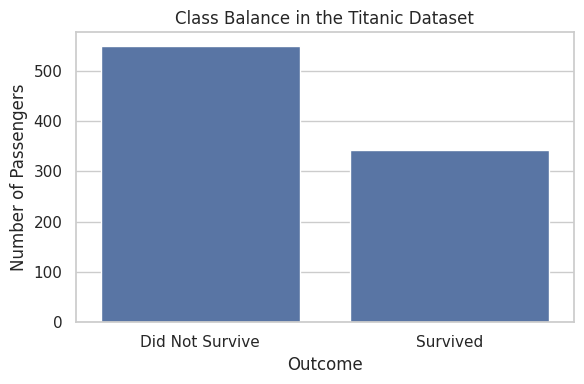

In [10]:
plt.figure(figsize=(6, 4))

sns.countplot(x='Survived', data=df)

plt.xticks([0, 1], ['Did Not Survive', 'Survived'])
plt.xlabel('Outcome')
plt.ylabel('Number of Passengers')
plt.title('Class Balance in the Titanic Dataset')
plt.tight_layout()
plt.show()

### Observation

The Titanic dataset is **moderately imbalanced**, not severely so roughly 62% did not survive and 38% did. This is a mild imbalance compared to problems like fraud detection or rare-disease screening, where the minority class can be under 1% of the data.

That distinction matters for honesty: the effect demonstrated below is real but modest here. On a genuinely skewed dataset the same effect becomes dramatic, which is exactly why the habit of looking past accuracy is worth building now on an easy example.

## 3. Why Accuracy Alone Can Be Misleading

Here is the argument in plain English.

**Accuracy simply counts what fraction of predictions were correct.** It treats every mistake as equally important and it ignores *which* class the model got wrong. That becomes a problem when one class dominates the data, because a model can score well just by always guessing the majority class and never learning anything at all.

The clearest way to prove this is to build a model that is deliberately useless — one that ignores every feature and always predicts "did not survive" and then measure its accuracy. If accuracy were a trustworthy measure on its own, this model should score terribly.

The cell below builds exactly that model. Watch what its accuracy turns out to be.

In [11]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 712
Testing samples: 179


In [12]:
# A deliberately useless model: always predict the majority class
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

print("Accuracy of a model that ALWAYS predicts 'did not survive':")
print(round(accuracy_score(y_test, dummy_pred) * 100, 2), "%")
print()
print("Unique predictions made by this model:", np.unique(dummy_pred))

Accuracy of a model that ALWAYS predicts 'did not survive':
61.45 %

Unique predictions made by this model: [0]


In [13]:
# The same useless model, judged on precision, recall and F1 instead
print(classification_report(
    y_test,
    dummy_pred,
    target_names=['Did Not Survive', 'Survived'],
    zero_division=0
))

                 precision    recall  f1-score   support

Did Not Survive       0.61      1.00      0.76       110
       Survived       0.00      0.00      0.00        69

       accuracy                           0.61       179
      macro avg       0.31      0.50      0.38       179
   weighted avg       0.38      0.61      0.47       179



### What just happened

The useless model scored a respectable-looking accuracy because simply guessing the majority class is right most of the time when that class is the majority. But `classification_report` exposes it immediately: **recall for the "Survived" class is 0.00**. The model found none of the survivors. It has no skill whatsoever, and accuracy alone hid that completely.

This is the whole lesson of the task. On a fraud dataset that is 99% legitimate transactions, a model that flags nothing at all scores 99% accuracy and catches zero fraud.

**The metrics that don't lie here:**

- **Precision** of the passengers the model predicted as survivors, what fraction actually survived? *Answers: when it raises its hand, can we trust it?*
- **Recall** of the passengers who actually survived, what fraction did the model find? *Answers: how many did it miss?*
- **F1-score** the harmonic mean of precision and recall, which stays low unless **both** are decent. A single number that cannot be gamed by ignoring a class.

Which one matters most depends on the cost of each error. Missing a fraudulent transaction is worse than reviewing a legitimate one, so fraud detection prioritises recall. Flagging a healthy patient for invasive surgery is costly too, so the balance shifts by domain.

## 4. Baseline Model (Task 3 Reproduction)

This rebuilds the Task 3 pipeline exactly same features, same `OneHotEncoder`, same 80/20 split with `random_state=42` and `stratify=y`, same `LogisticRegression(max_iter=1000)`.

The accuracy printed below should match the **80.45%** recorded in Task 3. If it does, the baseline is faithfully reproduced and the before/after comparison later is trustworthy.

In [14]:
categorical_features = ['Sex', 'Embarked']
numerical_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

# Identical preprocessing to Task 3: encode categoricals, pass numericals through
baseline_preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('numerical', 'passthrough', numerical_features)
    ]
)

baseline_model = Pipeline(
    steps=[
        ('preprocessor', baseline_preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ]
)

baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sex', 'Embarked']),
                                                 ('numerical', 'passthrough',
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [15]:
baseline_pred = baseline_model.predict(X_test)

print("Baseline accuracy:", round(accuracy_score(y_test, baseline_pred), 4))
print("Baseline accuracy percentage:", round(accuracy_score(y_test, baseline_pred) * 100, 2), "%")
print()
print("Confusion matrix:")
print(confusion_matrix(y_test, baseline_pred))

Baseline accuracy: 0.8045
Baseline accuracy percentage: 80.45 %

Confusion matrix:
[[98 12]
 [23 46]]


### Baseline classification report

Now the same model judged properly on precision, recall and F1 rather than accuracy alone.

In [16]:
print(classification_report(
    y_test,
    baseline_pred,
    target_names=['Did Not Survive', 'Survived']
))

                 precision    recall  f1-score   support

Did Not Survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



### Reading this report

Look specifically at the **"Survived" row**, since that is the minority class and the one the useless model failed on entirely.

Compare its recall against the recall for "Did Not Survive". A gap between the two means the model is noticeably better at identifying deaths than survivals a bias toward the majority class that accuracy averages away into a single comfortable number.

Also note the two summary rows at the bottom. **Macro average** treats both classes as equally important; **weighted average** weights them by how many passengers are in each class. The weighted average will sit closer to the accuracy figure, because it inherits the same majority-class bias.

## 5. Hyperparameter Tuning with GridSearchCV

A **hyperparameter** is a setting chosen *before* training, rather than learned from the data. In Task 3 these were left at their defaults effectively a guess.

`GridSearchCV` replaces guessing with a systematic search. It tries every combination in a grid, evaluates each one using **cross-validation** on the training data, and keeps the best.

**Cross-validation** (here `cv=5`) splits the training data into 5 parts, trains on 4 and validates on the remaining 1, then rotates through all 5. Every combination is therefore scored on data it did not train on. Crucially, the *test set is never touched during tuning* — it stays sealed for the final comparison, otherwise the tuned model would look better than it truly is.

**Hyperparameters being tuned (three, exceeding the two required):**

| Hyperparameter | What it controls |
|---|---|
| `C` | Regularization strength. Small values force simpler models that generalise more; large values let the model fit the training data more closely. |
| `solver` | The optimisation algorithm used to fit the model. Different solvers can converge to slightly different solutions. |
| `class_weight` | Whether to weight classes equally or compensate for the imbalance. `'balanced'` makes minority-class mistakes count for more. |

**Scoring choice:** the search optimises for **F1 on the survived class**, not accuracy. This is the whole point of the task tuning for accuracy would just reward the majority-class bias we are trying to fix.

In [17]:
# The tuned pipeline adds StandardScaler to the numerical features.
# This is deliberate: regularization strength C is sensitive to feature scale,
# and Fare ranges from 0 to 512 while Pclass only ranges from 1 to 3.
tuned_preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('numerical', StandardScaler(), numerical_features)
    ]
)

tuned_pipeline = Pipeline(
    steps=[
        ('preprocessor', tuned_preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ]
)

In [18]:
# Parameter names use the 'stepname__parameter' format so the pipeline
# knows which step each setting belongs to.
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__class_weight': [None, 'balanced'],
    'classifier__solver': ['lbfgs', 'liblinear']
}

total_combinations = 5 * 2 * 2
print("Combinations to try:", total_combinations)
print("Models to train (with 5-fold CV):", total_combinations * 5)

Combinations to try: 20
Models to train (with 5-fold CV): 100


In [19]:
grid_search = GridSearchCV(
    estimator=tuned_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('categorical',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Sex',
                                                                          'Embarked']),
                                                                        ('numerical',
                                                                         StandardScaler(),
                                                                         ['Pclass',
                                                                          'Age',
                                                                          'SibSp',
                                                                          'Parch',
                                                                          'Fare'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100],
                         'classifier__class_weight': [None, 'balanced'],
                         'classifier__solver': ['lbfgs', 'liblinear']},
             scoring='f1')

In [20]:
print("Best hyperparameters found:")
for name, value in grid_search.best_params_.items():
    print("  ", name, "=", value)

print()
print("Best cross-validated F1 score:", round(grid_search.best_score_, 4))

Best hyperparameters found:
   classifier__C = 0.01
   classifier__class_weight = balanced
   classifier__solver = liblinear

Best cross-validated F1 score: 0.746


### Inspecting the search results

It is worth looking at the top few combinations rather than only the winner. If several very different settings score almost identically, the choice between them matters less than it appears.

In [21]:
results = pd.DataFrame(grid_search.cv_results_)

top_results = results[[
    'param_classifier__C',
    'param_classifier__class_weight',
    'param_classifier__solver',
    'mean_test_score',
    'std_test_score'
]].sort_values('mean_test_score', ascending=False).head(10)

print(top_results.to_string(index=False))

 param_classifier__C param_classifier__class_weight param_classifier__solver  mean_test_score  std_test_score
                0.01                       balanced                liblinear         0.746004        0.026992
                0.01                       balanced                    lbfgs         0.735532        0.023222
              100.00                       balanced                    lbfgs         0.731395        0.021815
              100.00                       balanced                liblinear         0.731395        0.021815
               10.00                       balanced                    lbfgs         0.731395        0.021815
               10.00                       balanced                liblinear         0.731395        0.021815
                0.10                       balanced                    lbfgs         0.729717        0.030666
                1.00                       balanced                liblinear         0.728926        0.026397
          

## 6. Evaluating the Tuned Model

The best model found by the search is now evaluated on the **test set** the data that was sealed off during tuning.

In [22]:
tuned_model = grid_search.best_estimator_

tuned_pred = tuned_model.predict(X_test)

print("Tuned accuracy:", round(accuracy_score(y_test, tuned_pred), 4))
print()
print("Confusion matrix:")
print(confusion_matrix(y_test, tuned_pred))

Tuned accuracy: 0.7765

Confusion matrix:
[[86 24]
 [16 53]]


In [23]:
print(classification_report(
    y_test,
    tuned_pred,
    target_names=['Did Not Survive', 'Survived']
))

                 precision    recall  f1-score   support

Did Not Survive       0.84      0.78      0.81       110
       Survived       0.69      0.77      0.73        69

       accuracy                           0.78       179
      macro avg       0.77      0.77      0.77       179
   weighted avg       0.78      0.78      0.78       179



## 7. Before / After Comparison

All four metrics side by side. Precision, recall and F1 below are calculated for the **"Survived" class**, since that is the minority class we care about improving.

In [24]:
def get_metrics(y_true, y_pred):
    """Return the four headline metrics for the positive (Survived) class."""
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }

baseline_metrics = get_metrics(y_test, baseline_pred)
tuned_metrics = get_metrics(y_test, tuned_pred)

comparison = pd.DataFrame({
    'Before (Task 3)': baseline_metrics,
    'After (Tuned)': tuned_metrics
})

comparison['Change'] = comparison['After (Tuned)'] - comparison['Before (Task 3)']

print(comparison.round(4).to_string())

           Before (Task 3)  After (Tuned)  Change
Accuracy            0.8045         0.7765 -0.0279
Precision           0.7931         0.6883 -0.1048
Recall              0.6667         0.7681  0.1014
F1-Score            0.7244         0.7260  0.0016


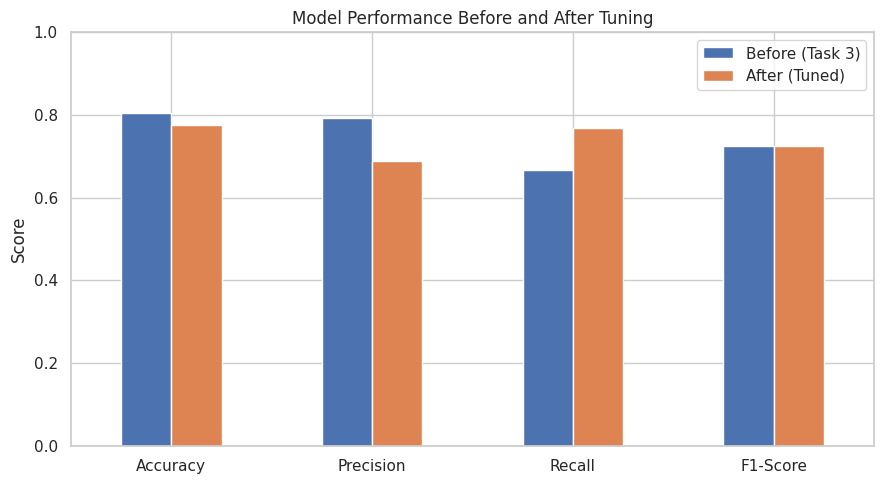

In [25]:
# Same table as a grouped bar chart
plot_data = comparison[['Before (Task 3)', 'After (Tuned)']]

plot_data.plot(kind='bar', figsize=(9, 5), rot=0)

plt.ylabel('Score')
plt.title('Model Performance Before and After Tuning')
plt.ylim(0, 1)
plt.legend(title='')
plt.tight_layout()
plt.show()

### Confusion matrices side by side

The tables above summarise performance; the confusion matrices show *where* the predictions changed.

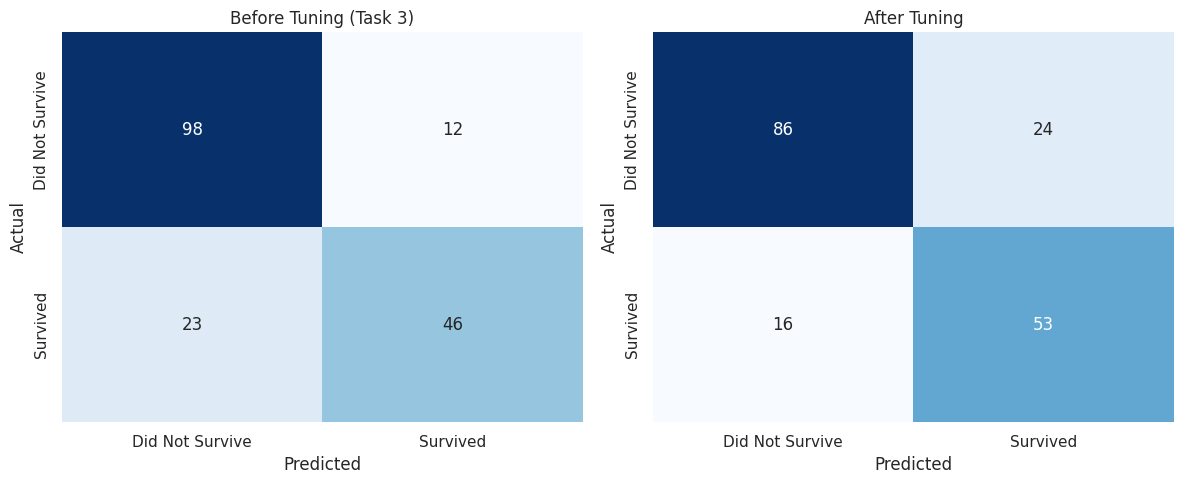

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['Did Not Survive', 'Survived']

for ax, preds, title in zip(
    axes,
    [baseline_pred, tuned_pred],
    ['Before Tuning (Task 3)', 'After Tuning']
):
    sns.heatmap(
        confusion_matrix(y_test, preds),
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=labels,
        yticklabels=labels,
        ax=ax
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

plt.tight_layout()
plt.show()

### How to read the change

Compare the bottom-left cell of each matrix those are survivors the model wrongly predicted as deaths (**false negatives**). Compare the top-right cell too passengers wrongly predicted as survivors (**false positives**).

There is usually a **trade-off** between precision and recall. If tuning pushed recall up, the model became more willing to predict "survived", which catches more real survivors but also produces more false alarms so precision often falls at the same time. F1 is the metric that tells you whether the overall balance genuinely improved or simply shifted.

Do not be alarmed if accuracy went *down* slightly while F1 went up. That is not a failure. It means the model stopped inflating its score by favouring the majority class, which is precisely what tuning for F1 was meant to achieve.

## 8. Summary

**What this notebook demonstrated**

1. A model that always predicts the majority class scores a respectable accuracy while having zero real skill proof that accuracy alone is not a sufficient measure.
2. `classification_report` exposes that failure instantly through precision, recall and F1 per class.
3. `GridSearchCV` with 5-fold cross-validation tuned three hyperparameters (`C`, `class_weight`, `solver`) systematically instead of by guesswork.
4. The search optimised **F1 on the minority class** rather than accuracy, so the tuned model is judged on the metric that actually reflects skill.
5. A before/after table and paired confusion matrices show exactly what changed.

**Honest limitations**

- Titanic's imbalance is mild (62/38). The lesson generalises, but the size of the improvement here is modest compared to a genuinely skewed dataset.
- The test set has only 179 rows, so small metric differences are within noise. A change of one or two percentage points should not be treated as a meaningful improvement.
- Only Logistic Regression was tuned. Trying a different algorithm entirely (Random Forest, Gradient Boosting) would likely produce a larger gain than tuning this one.